# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

This data represents 17 marketing campaigns. "The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts."

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df['Output'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)


print(df.head(5))

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  pdays  previous     poutcome  emp.var.rate  \
0   may         mon  ...    999         0  nonexistent           1.1   
1   may         mon  ...    999         0  nonexistent           1.1   
2   may         mon  ...    999         0  nonexistent           1.1   
3   may         mon  ...    999         0  nonexistent           1.1   
4   may         mon  ...    999         0  nonexistent           1.1   

  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y  Output  
0         93.994          -36.4      4.8

/tmp/ipython-input-6-2048320717.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="y", data=df, palette="pastel")


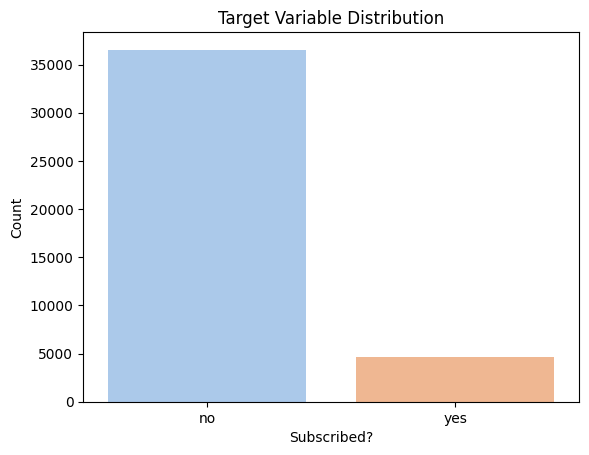

In [6]:
# Visual for target variable distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="y", data=df, palette="pastel")
plt.title("Target Variable Distribution")
plt.xlabel("Subscribed?")
plt.ylabel("Count")
plt.show()

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



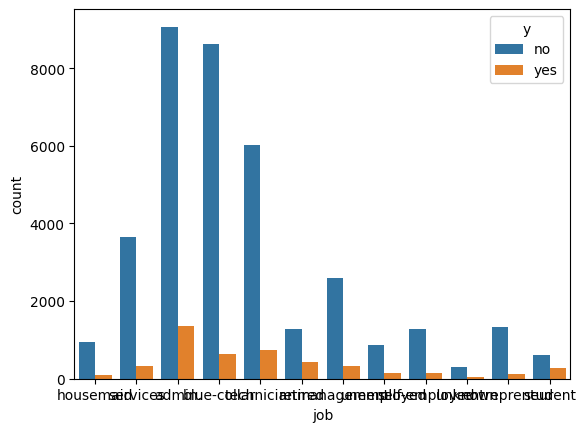

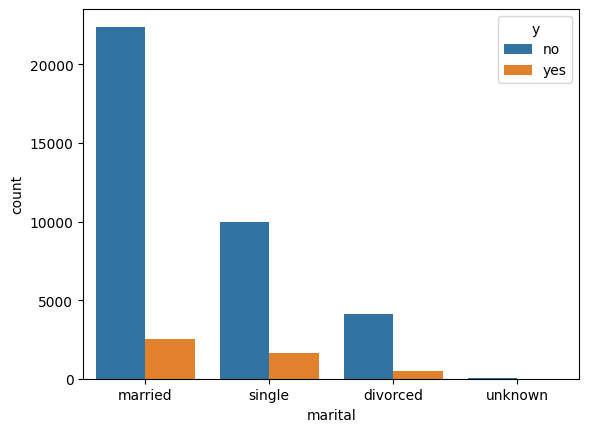

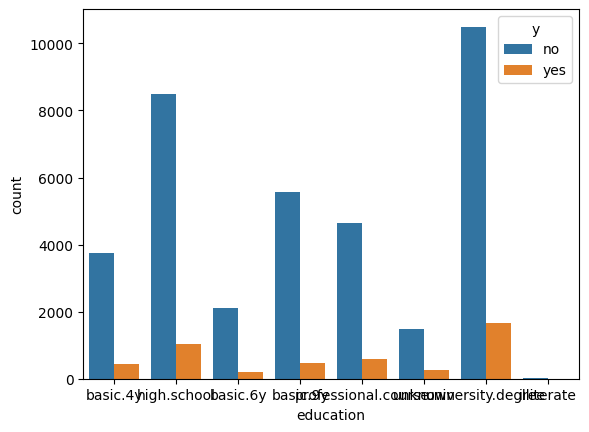

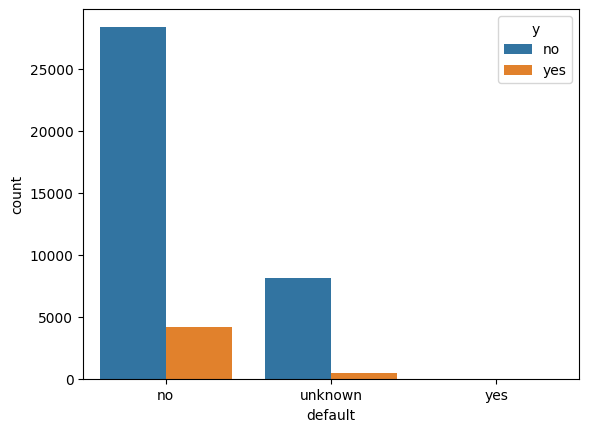

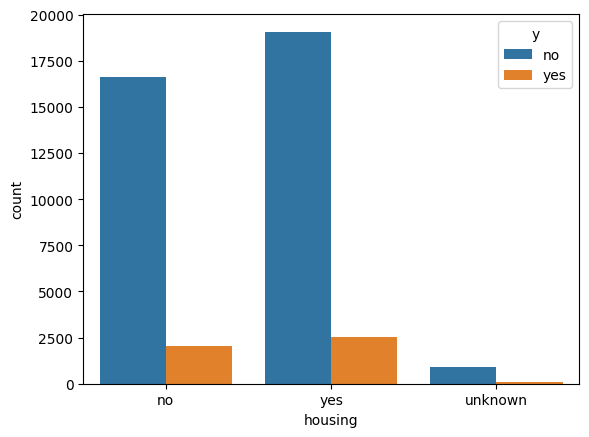

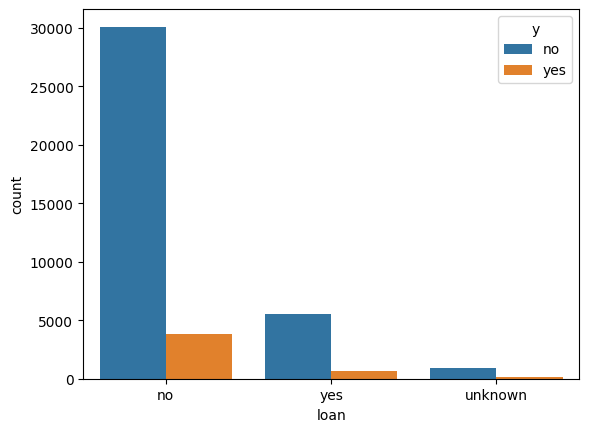

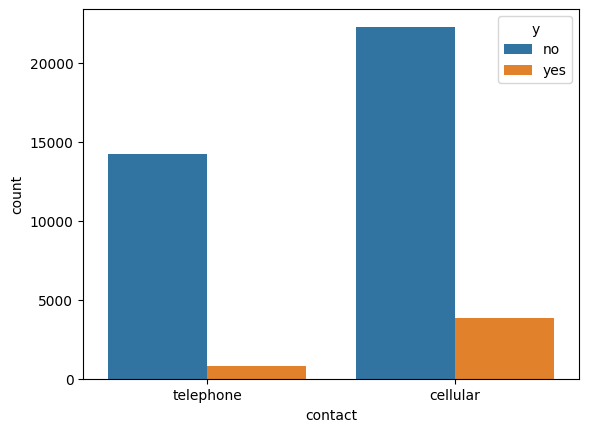

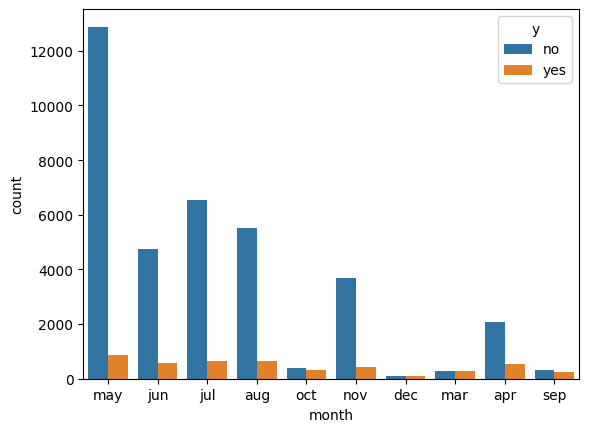

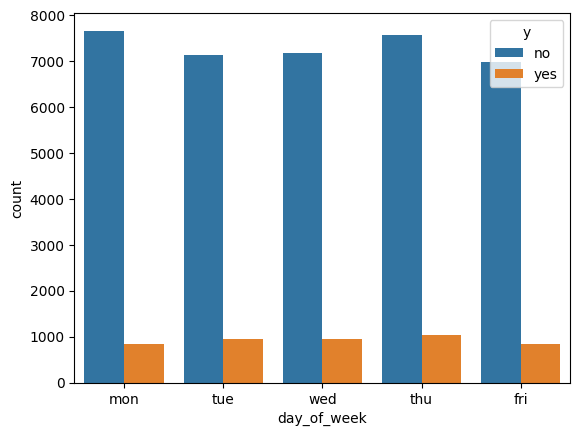

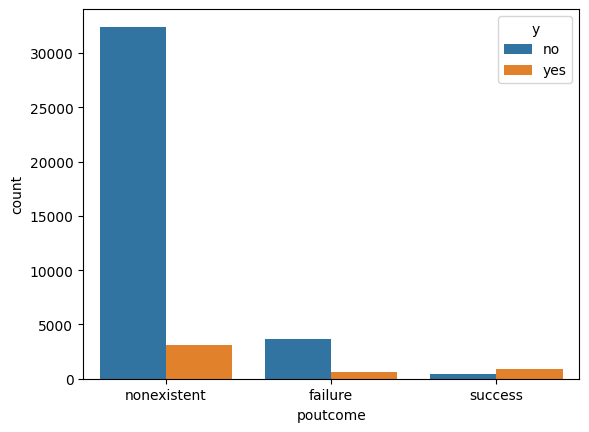

In [7]:
# Visualization for cat features
cat_features = df.select_dtypes(include="object").drop(columns="y").columns

for col in cat_features:
    sns.countplot(x=col, hue="y", data=df)
    plt.show()

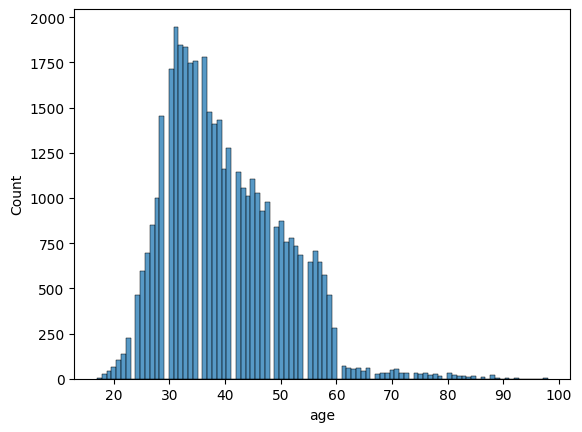

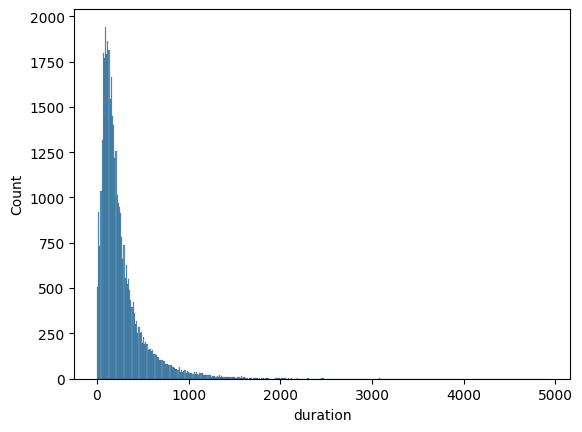

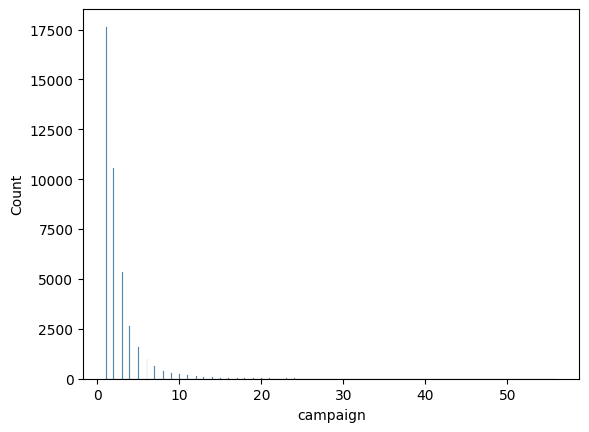

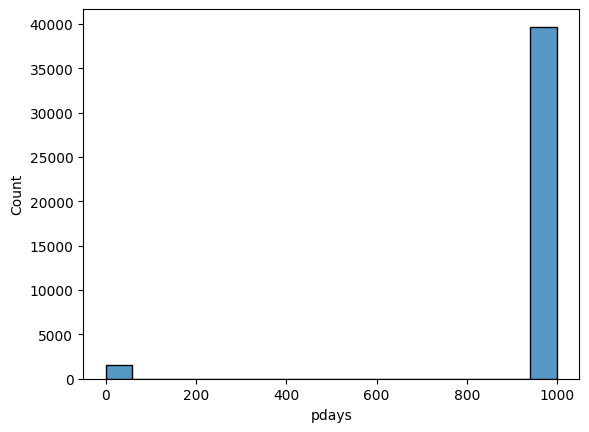

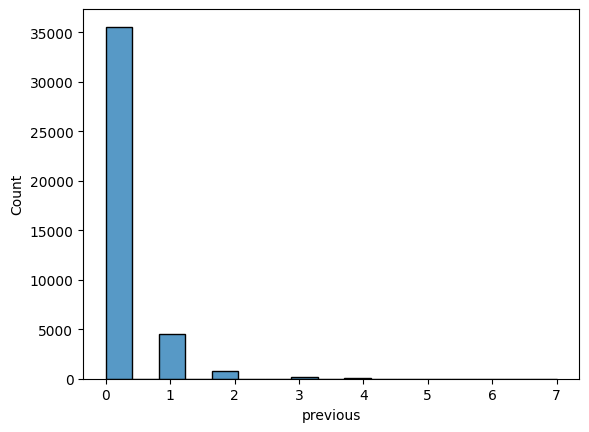

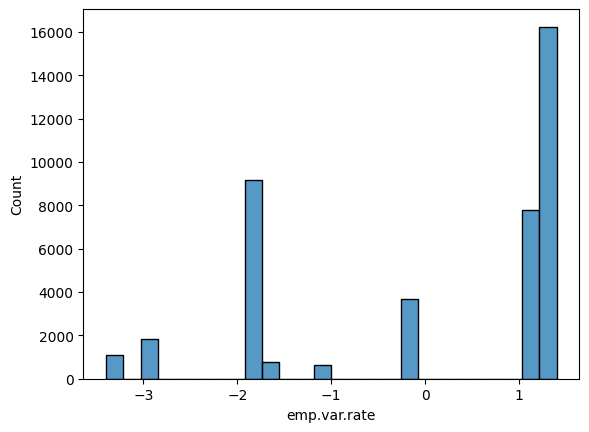

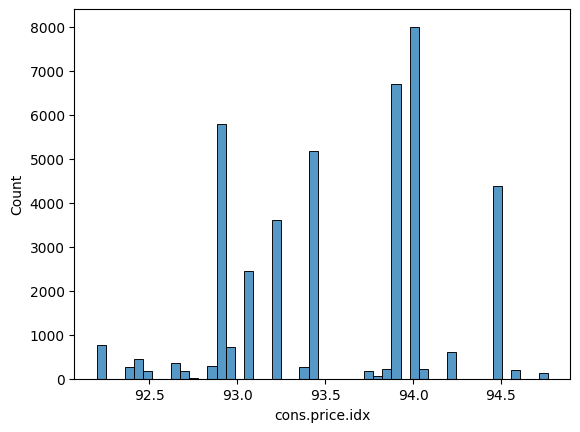

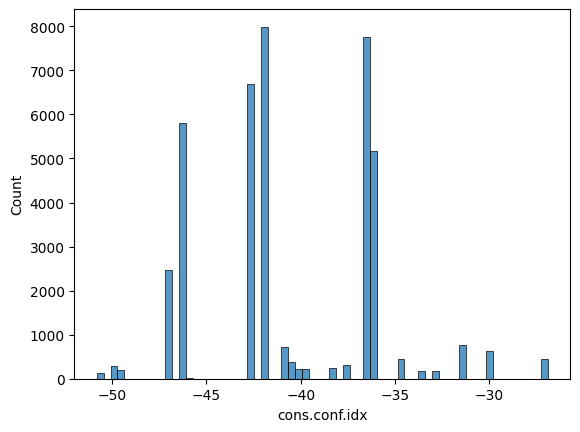

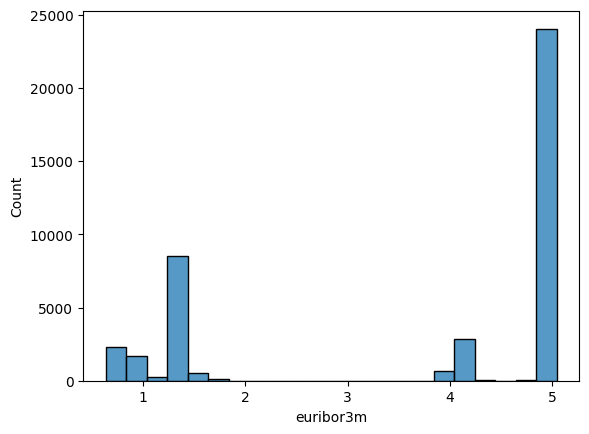

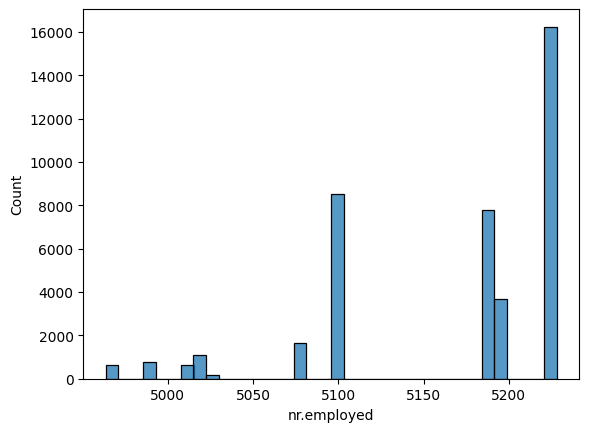

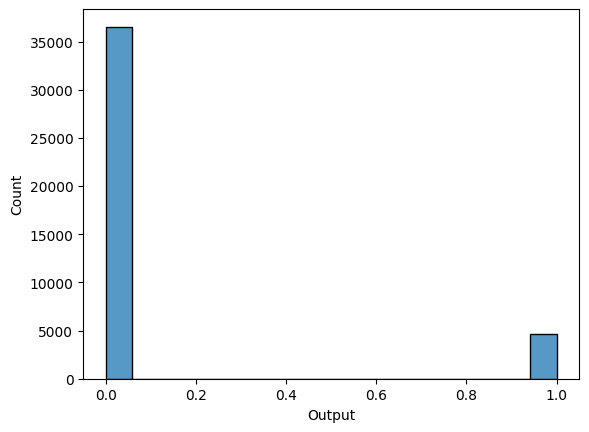

In [8]:
# and visual for numerical features
num_features = df.select_dtypes(include="number").columns

for col in num_features:
    sns.histplot(df[col])
    plt.show()

From the descriptions alone:


*   We should handle the columns which have 'unknown' values - job, martial, education, default, housing, loan
* pdays 999 value probably should be changed to something else. Does 0 make sense? That kind of implies the opposite - that someone was just contacted rather than not previously contacted.




In [9]:
# How many 'unknown' values are there actually per column
unknown_counts = (df == 'unknown').sum()

# Also, what is the most common value per column to see if replacing the values makes sense vs. dropping
most_common_values = df.mode().iloc[0]

# Combine into a DataFrame
summary_df = pd.DataFrame({'Unknown Count': unknown_counts, 'Most Common Value': most_common_values})

# And we have 41,188 rows in the df

summary_df = pd.DataFrame({
    'Unknown Count': unknown_counts,
    'Most Common Value': most_common_values
})

# So default column has like 20% of the values are just NaN
print (summary_df)

                Unknown Count  Most Common Value
age                         0               31.0
job                       330             admin.
marital                    80            married
education                1731  university.degree
default                  8597                 no
housing                   990                yes
loan                      990                 no
contact                     0           cellular
month                       0                may
day_of_week                 0                thu
duration                    0                 85
campaign                    0                1.0
pdays                       0              999.0
previous                    0                0.0
poutcome                    0        nonexistent
emp.var.rate                0                1.4
cons.price.idx              0             93.994
cons.conf.idx               0              -36.4
euribor3m                   0              4.857
nr.employed         

In [10]:
missing_counts = df.isna().sum()

# Count empty string values explicitly
empty_counts = (df == '').sum()

# Combine both counts
total_missing = missing_counts + empty_counts

print(total_missing)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
Output            0
dtype: int64


In [11]:
print(df.isnull().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
Output            0
dtype: int64


In [12]:
# Default is the main column that has the highest % of missing values in relation to the dataset.
# What is the distribution (% no/yes/unknown) so we can figure out what to do with those 'unknown' values.

print("Distribution of 'default' for non-missing rows:")
print(df[df['default'].notna()]['default'].value_counts(normalize=True))

print("Distribution of 'default' for missing rows:")
print(df[df['default'].isna()]['default'].value_counts(normalize=True))


Distribution of 'default' for non-missing rows:
default
no         0.791201
unknown    0.208726
yes        0.000073
Name: proportion, dtype: float64
Distribution of 'default' for missing rows:
Series([], Name: proportion, dtype: float64)


We should probably have an imputation strategy - just dropping 'unknown' rows would be a significant portion of the data, which also might mean that we would miss out on some relationships during analysis.


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

*Business Objective:* The business objective of this task is to predict whether or not someone will subscribe to along-term deposit.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

One-Hot Encoding
"In Pandas, the get_dummies() function converts categorical variables into dummy/indicator variables (known as one-hot encoding). This method is especially useful when preparing data for machine learning algorithms that require numeric input."

Source: https://www.geeksforgeeks.org/python-pandas-get_dummies-method/

Google says: The drop_first parameter, when set to True, helps avoid the "dummy variable trap" in statistical modeling.

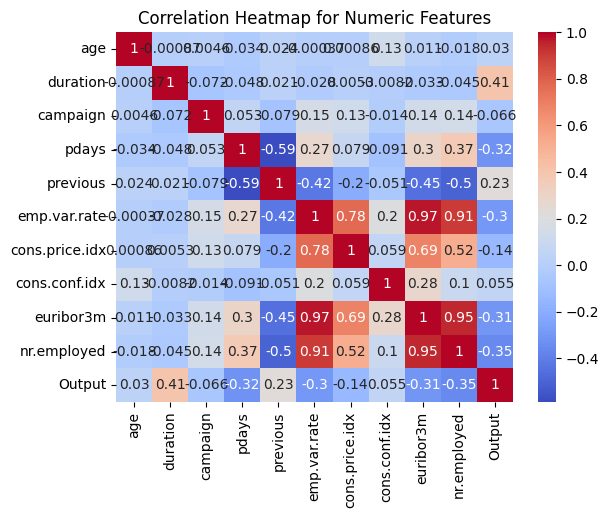

In [13]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap for Numeric Features")
plt.show()

In [14]:
print(df)

       age          job  marital            education  default housing loan  \
0       56    housemaid  married             basic.4y       no      no   no   
1       57     services  married          high.school  unknown      no   no   
2       37     services  married          high.school       no     yes   no   
3       40       admin.  married             basic.6y       no      no   no   
4       56     services  married          high.school       no      no  yes   
...    ...          ...      ...                  ...      ...     ...  ...   
41183   73      retired  married  professional.course       no     yes   no   
41184   46  blue-collar  married  professional.course       no      no   no   
41185   56      retired  married    university.degree       no     yes   no   
41186   44   technician  married  professional.course       no      no   no   
41187   74      retired  married  professional.course       no     yes   no   

         contact month day_of_week  ...  pdays  pre

In [15]:
# Categorical columns to encode
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

# One-hot encoding
cols_encoded = pd.get_dummies(df[cat_cols], drop_first=True)

# Merge encoded columns with the rest of the DataFrame
df_encoded = pd.concat([df.drop(columns=cat_cols), cols_encoded], axis=1)

# Encode the target column
df_encoded['y'] = df_encoded['y'].map({'no': 0, 'yes': 1})

# Drop duration column as recommended by data description above re: ""
# Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Thus, this input
# should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model
df_encoded = df_encoded.drop(columns=['duration'])

print(df_encoded)

       age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0       56         1    999         0           1.1          93.994   
1       57         1    999         0           1.1          93.994   
2       37         1    999         0           1.1          93.994   
3       40         1    999         0           1.1          93.994   
4       56         1    999         0           1.1          93.994   
...    ...       ...    ...       ...           ...             ...   
41183   73         1    999         0          -1.1          94.767   
41184   46         1    999         0          -1.1          94.767   
41185   56         2    999         0          -1.1          94.767   
41186   44         1    999         0          -1.1          94.767   
41187   74         3    999         1          -1.1          94.767   

       cons.conf.idx  euribor3m  nr.employed  y  ...  month_may  month_nov  \
0              -36.4      4.857       5191.0  0  ...       True      

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df_encoded = df_encoded.drop(columns=['y'])

X = df_encoded.drop(columns=['Output'])
y = df_encoded['Output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (27595, 52)
X_test shape: (13593, 52)
y_train shape: (27595,)
y_test shape: (13593,)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

The baseline performance that our classifier should aim to beat is 88.73%

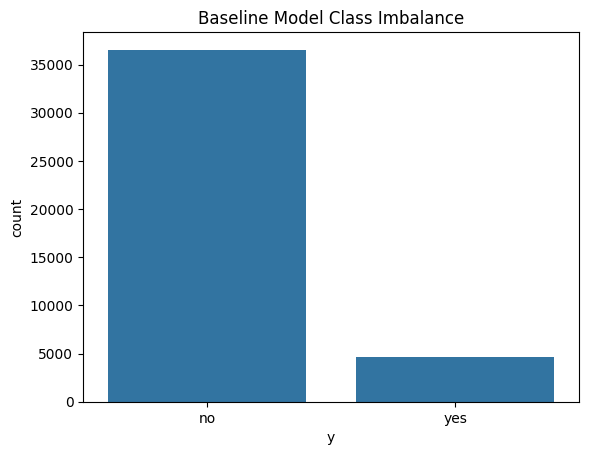

In [17]:
sns.countplot(x="y", data=df)
plt.title("Baseline Model Class Imbalance")
plt.show()

In [18]:
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.887346
yes,0.112654


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [19]:
X = df_encoded.drop(columns=['Output'])
y = df_encoded['Output']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

### Problem 9: Score the Model

What is the accuracy of your model?

The accuracy of the Log Reg model is 90.05% (about 1.32% higher than baseline).

In [20]:
y_pred = logreg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.9005


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [21]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

timingResults = []

In [22]:
models = [
    ("Logistic Regression", LogisticRegression()),
    ("KNN", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier()),
    ("SVM", SVC())
]

for name, model in models:
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    train_time = round(end - start, 4)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    timingResults.append([name, train_time, round(train_acc, 4), round(test_acc, 4)])

# Present results
results_df = pd.DataFrame(timingResults, columns=["Model", "Train Time (s)", "Train Accuracy", "Test Accuracy"])
results_df

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic Regression,2.0401,0.8997,0.8992
1,KNN,0.0433,0.9141,0.8879
2,Decision Tree,0.2469,0.9956,0.8367
3,SVM,12.7603,0.8978,0.8968


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.

- More feature engineering and exploration.  For example, should we keep the gender feature?  Why or why not?
- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [23]:
# Lets try to figure out which columns are the "least helpful" i.e. have the least correlation with the target.

df_encoded.corr(numeric_only=True)['Output'].sort_values()

,Output
nr.employed,-0.354678
pdays,-0.324914
euribor3m,-0.307771
emp.var.rate,-0.298334
poutcome_nonexistent,-0.193507
contact_telephone,-0.144773
cons.price.idx,-0.136211
month_may,-0.108271
default_unknown,-0.099293
job_blue-collar,-0.074423


First lets try the suggested above:
Hyperparameter tuning and grid search. All of our models have additional hyperparameters to tune and explore. For example the number of neighbors in KNN or the maximum depth of a Decision Tree.

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_params = {
    'n_neighbors': list(range(3, 22, 2)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

y_pred = grid_knn.predict(X_test)

# Results
print("Best Parameters:", grid_knn.best_params_)
print("Best CV Accuracy:", round(grid_knn.best_score_, 4))

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'n_neighbors': 21, 'p': 1, 'weights': 'uniform'}
Best CV Accuracy: 0.8977
Test Accuracy: 0.8977

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94     10968
           1       0.61      0.24      0.35      1389

    accuracy                           0.90     12357
   macro avg       0.76      0.61      0.65     12357
weighted avg       0.88      0.90      0.88     12357



In [ ]:
# Even more neighbors! And using p 1 and uniform/distance weights

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_params = {
    'n_neighbors': list(range(21, 62, 2)),
    'weights': ['uniform', 'distance'],
    'p': [1]
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

y_pred = grid_knn.predict(X_test)

# Results
print("Best Parameters:", grid_knn.best_params_)
print("Best CV Accuracy:", round(grid_knn.best_score_, 4))

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
tree_params = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), tree_params, cv=5, scoring='accuracy')
grid_tree.fit(X_train, y_train)

y_pred_tree = grid_tree.predict(X_test)


# Results
print("Best Parameters:", grid_tree.best_params_)
print("Best CV Accuracy:", round(grid_tree.best_score_, 4))

print("Test Accuracy:", round(accuracy_score(y_test, y_pred_tree), 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))


Now that we have the above, lets try the above again with the updated data (minus the 10 "lowest impact" features).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

## Try to figure out which columns we can drop
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns)
low_importance = importances.sort_values().head(10)
print(low_importance)

In [ ]:
low_prio_features = [
    'default_yes', 'education_illiterate', 'marital_unknown', 'month_dec',
    'job_unknown', 'month_nov', 'month_aug', 'month_sep',
    'month_jul', 'month_jun'
]

prio_modified_features = X.drop(columns=low_prio_features)

print("Original shape:", X.shape)
print("Minus 10 lowest prio shape:", prio_modified_features.shape)

In [ ]:
X_train_better_prio, X_test_better_prio, y_train_better_prio, y_test_better_prio = train_test_split(
    prio_modified_features, y, test_size=0.3, random_state=42)

print("X_train_better_prio shape:", X_train_better_prio.shape)
print("X_test_better_prio shape:", X_test_better_prio.shape)

In [ ]:
grid_knn = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='accuracy')
grid_knn.fit(X_train_better_prio, y_train_better_prio)

y_pred = grid_knn.predict(X_test_better_prio)

print("Best Parameters:", grid_knn.best_params_)
print("Best CV Accuracy:", round(grid_knn.best_score_, 4))
print("Test Accuracy:", round(accuracy_score(y_test_better_prio, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test_better_prio, y_pred))


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_better_prio)

# Confusion matrix
cm_knn = confusion_matrix(y_test_better_prio, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=best_knn.classes_)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix - KNN")
plt.show()


In [ ]:
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), tree_params, cv=5, scoring='accuracy')
grid_tree.fit(X_train_better_prio, y_train_better_prio)

y_pred_tree = grid_tree.predict(X_test_better_prio)

print("Best Parameters:", grid_tree.best_params_)
print("Best CV Accuracy:", round(grid_tree.best_score_, 4))
print("Test Accuracy:", round(accuracy_score(y_test_better_prio, y_pred_tree), 4))
print("\nClassification Report:\n", classification_report(y_test_better_prio, y_pred_tree))


In [ ]:
best_tree = grid_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test_better_prio)

# Confusion matrix
cm_tree = confusion_matrix(y_test_better_prio, y_pred_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=best_tree.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Since the majority of people respond “no”, we should care more about correctly identifying the smaller group who would say “yes” since these are our potential customers.

So, that means that accuracy isn’t very helpful, because a model could be ~89% accurate but always predicting “no" (which doesn't give us much insight into our goal). Metrics like recall, precision, and F1-score are probably more meaningful here such that:
- Recall helps us ensure we don't miss actual subscribers
- Precision ensures we don’t waste resources on people unlikely to subscribe
- F1-score to balance both

In [ ]:
from sklearn.metrics import roc_auc_score

y_proba_tree = grid_tree.best_estimator_.predict_proba(X_test_better_prio)[:, 1]
print("ROC AUC Score:", round(roc_auc_score(y_test_better_prio, y_proba_tree), 4))


In [ ]:
best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test_better_prio)
y_proba_knn = best_knn.predict_proba(X_test_better_prio)[:, 1]

print("Classification Report (KNN):\n", classification_report(y_test_better_prio, y_pred_knn))
print("ROC AUC Score (KNN):", round(roc_auc_score(y_test_better_prio, y_proba_knn), 4))

Lets also run it on Log Reg (original baseline) but without 10 low prio features

In [ ]:
logreg_better = LogisticRegression(max_iter=1000)
logreg_better.fit(X_train_better_prio, y_train_better_prio)

y_pred_logreg = logreg_better.predict(X_test_better_prio)
y_proba_logreg = logreg_better.predict_proba(X_test_better_prio)[:, 1]

print("Test Accuracy:", round(accuracy_score(y_test_better_prio, y_pred_logreg), 4))
print("Classification Report (LogReg):\n", classification_report(y_test_better_prio, y_pred_logreg))
print("ROC AUC Score (LogReg):", round(roc_auc_score(y_test_better_prio, y_proba_logreg), 4))

In [ ]:
y_pred_logreg = logreg_better.predict(X_test_better_prio)

cm_logreg = confusion_matrix(y_test_better_prio, y_pred_logreg)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=logreg_better.classes_)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

##### Findings

For this project, our main goal was to accurately predict which customers are likely to say “yes” to a term deposit to enable the bank to optimize marketing efforts and reduce wasted outreach.

We established a baseline to start: predicting the majority class ("no") would have 88.73% accuracy.

Though accuracy is typically an important metric, I focused on recall, precision, F1-score, and ROC AUC because they more accurately reflected model performance given the class imbalance. Specifically:
- Recall: We don't want to miss real subscribers to a term deposit
- Precision: We'd like to avoid wasting effort on those that are unlikely to say yes (i.e. more likely not to subscribe)
- F1 score: As a balance of the 2 above (recall + precision)
- ROC AUC: to help us rank/separate how well our model is able to separate non-subscribers from subscribers. Given the dataset imbalance, this metric helps us evaluate how good the model is at ranking and not just classifying customers.

______
For feature engineering, I one-hot encoded categorical features, dropped the "Duration" column per the dataset's documentation, and also removed the 10 lowest-importance features based on a Random Forest feature importance.

| Metric       | Before (52 features) | After (42 features) |
| ------------ | -------------------- | ------------------- |
| Accuracy     | \~90.05%             | \~90.02%            |
| ROC AUC      | \~0.7823             | \~0.7826            |
| Recall (Yes) | \~0.22               | \~0.22              |

These results confirmed that the 10 features removed did in fact add little signal and removing them did not sacrifice predictive quality.

____


Then, to tune the model I use various hyperparamters for KNN, Decision Tree, and also re-evaluated Logistic Regression since that was our original baseline. I also used GridSearchCV to ensure each model was tuned fairly and not under- or overfitting due to poor hyperparameter choices.


KNN best params: k=41, p=1, weights='uniform'

Decision Tree best params: max_depth=3, criterion='gini', min_samples_split=2
___

### Findings Summary

- Logistic Regression performed the best overall and had the highest ROC AUC with a good balance of precision/recall (even without tuning).
    - Highest ROC AUC & F1
- Grid search helped "level the playing field" for all the models, but Logistic Regression (simpler model) still performed the best
- Accuracy is not the best metric due to the class imbalance of the dataset. Instead, leveraging recall, precision, F1, and ROC AUC were better in evaluating the model usefulness / performance towards our goal.
- Feature selection via removing 10 of the lowest importance/indicator features helped to simplify the model without impacting performance.


### Future Improvements
- Adjusting the decision threshold (ex: 0.5 -> 0.3)
- Class weighting to apply a higher weight on the minority class since our dataset is so imbalanced
    - Instead of "yes"/"no" weighing the same, make misclassifying "yes" as "no" to count 5x or something
- Some sort of ranking mechanism so instead of it being a "yes"/"no" (binary!) for subscribing, it uses a predicted probability for the outcome.
   - Application: it would allow the business to look at something like Top 10% of customers that are most likely to subscribe and then reach out to those customers accordingly.

| Model                      | Test Accuracy | Precision (Yes) | Recall (Yes) | F1-Score (Yes) | ROC AUC |
| -------------------------- | ------------- | --------------- | ------------ | -------------- | ------- |
| Logistic Regression (full) | \~0.9005      | \~0.65          | \~0.22       | \~0.33         | \~0.78  |
| KNN (tuned)                | \~0.8992      | \~0.65          | \~0.22       | \~0.33         | \~0.78  |
| Decision Tree (tuned)      | \~0.8992      | \~0.69          | \~0.19       | \~0.30         | \~0.77  |
